E-Commerce Customer Churn Dataset

import libraries

In [1]:
import numpy as np 
import pandas as pd
import sklearn 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

load data

In [2]:
features=pd.read_csv("D:/ML Projects/E-Commerce Customer Churn/data/raw/ecommerce_customer_features.csv")
target=pd.read_csv("D:/ML Projects/E-Commerce Customer Churn/data/raw/ecommerce_customer_targets.csv")

In [3]:
features.info()
features.describe()
features.head()
features['Customer_ID'].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

array(['0520df14-712d-4c69-a0c5-95a2e7dfc1ff',
       'a4013b3f-0688-4096-a194-6074be8ffec8',
       'eb870f2c-ed3d-4a21-a8ac-273fae69ea4f', ...,
       '6a5b9ad3-7488-40e9-95b7-ad0ea7354f51',
       '3306b81f-13df-4ae9-947d-deaaf7723279',
       '48867913-4bb5-4823-87f0-dd405e3970e4'],
      shape=(6000,), dtype=object)

In [4]:
features.shape

(6000, 15)

In [5]:
df=features.merge(target,how="inner",on="Customer_ID")


In [6]:
df.shape

(6000, 16)

In [7]:
df

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No


In [8]:
df['churned'].value_counts()

churned
No     5071
Yes     929
Name: count, dtype: int64

In [9]:
churn_rate=(929/6000)*100
churn_rate

15.483333333333333

الاجابه علي اول سؤال عدد العملاء الذين غادرو هي 929 ونسبتهم=15.48

In [10]:
df.columns

Index(['Customer_ID', 'account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'loyalty_member',
       'browsing_frequency_per_week', 'cart_abandonment_rate',
       'product_review_score_avg', 'engagement_score', 'satisfaction_score',
       'price_sensitivity_index', 'churned'],
      dtype='object')

Data Understanding

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [12]:
df.isnull().sum()

Customer_ID                    0
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.isna().sum()

Customer_ID                    0
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

In [15]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


EDA(Exploratory Data Analysis)

In [16]:
df.shape

(6000, 16)

In [17]:
df.head(5)

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


Encoding

In [18]:
df['churned'].value_counts()

churned
No     5071
Yes     929
Name: count, dtype: int64

In [19]:
from sklearn.preprocessing import LabelEncoder
df['churned']=LabelEncoder().fit_transform(df['churned'])
df.head(5)

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,0
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,0
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,0
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,0
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,0


In [20]:
df['loyalty_member'].value_counts()

loyalty_member
No     4915
Yes    1085
Name: count, dtype: int64

In [21]:
df['loyalty_member']=df['loyalty_member'].map({'No':0,'Yes':1})

In [22]:
df['loyalty_member'].value_counts()

loyalty_member
0    4915
1    1085
Name: count, dtype: int64

Relations

-Churn distribution

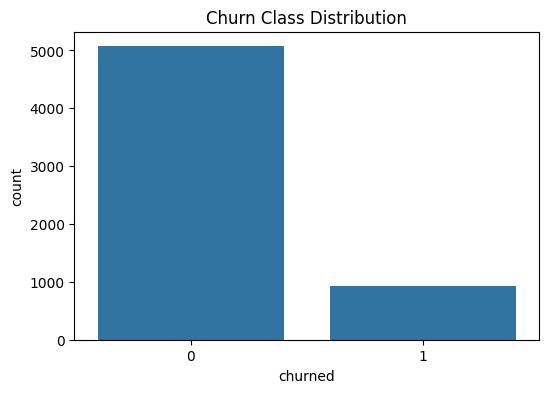

In [23]:
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(data=df,x='churned')
plt.title('Churn Class Distribution')
plt.show()


data is imbalanced

-loyalty_member VS churned

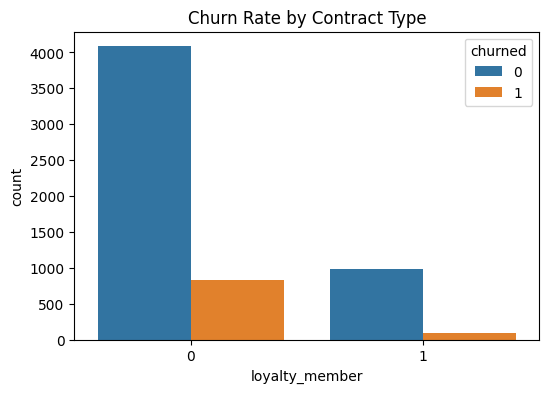

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df,x='loyalty_member',hue='churned')
plt.title('Churn Rate by Contract Type')
plt.show()

i will categorize the features 

-first relation between customer and website (how many monthes)

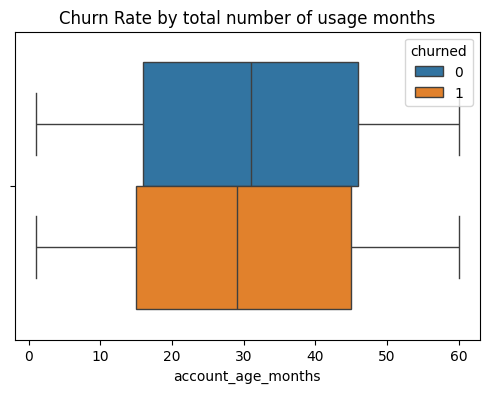

In [31]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x='account_age_months',hue='churned')
plt.title('Churn Rate by total number of usage months')
plt.show()

i see that the new coustomers is facing churn alittle bit than old customers

-Purchase Behavior (avg_order_value , total_orders)

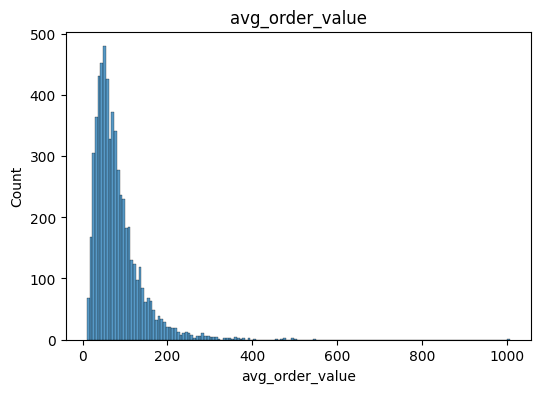

In [32]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='avg_order_value')
plt.title('avg_order_value')
plt.show()

Skweed to righte ===> the most of coutomers buy in range 20->200 egp

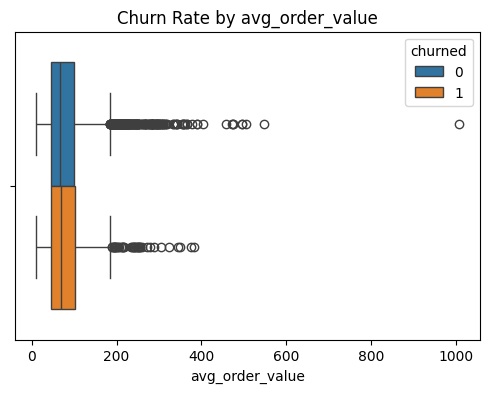

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x='avg_order_value',hue='churned')
plt.title('Churn Rate by avg_order_value')
plt.show()

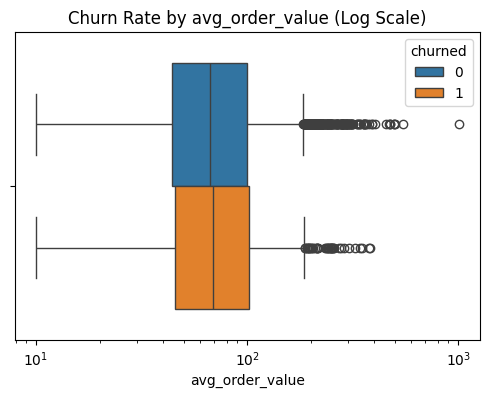

In [34]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='avg_order_value', hue='churned')
plt.xscale('log') # تحويل المحور لـ Logarithmic scale
plt.title('Churn Rate by avg_order_value (Log Scale)')
plt.show()

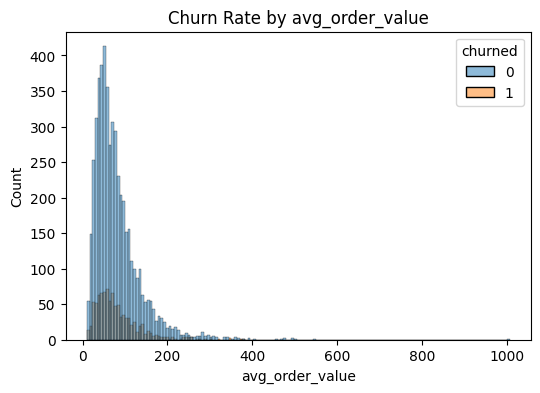

In [35]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='avg_order_value',hue='churned')
plt.title('Churn Rate by avg_order_value')
plt.show()

In [62]:
df.groupby('churned')['avg_order_value'].mean()

churned
0    80.472262
1    80.573552
Name: avg_order_value, dtype: float64

so the avg_order_value don't affect on the churn

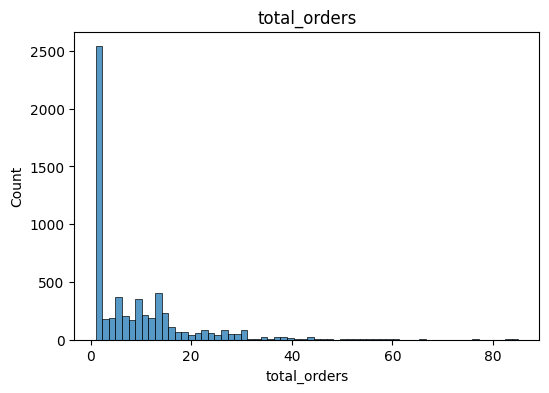

In [49]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='total_orders')
plt.title('total_orders')
plt.show()

In [48]:
df['total_orders'].value_counts(normalize=True).head(10) * 100

total_orders
1     39.366667
15     3.766667
13     3.583333
11     3.566667
7      3.350000
6      3.233333
4      3.183333
12     3.183333
14     3.166667
2      2.983333
Name: proportion, dtype: float64

In [47]:
len(df[df['total_orders'] ==1])

2362

this line mean that 39 % of customers buy one time only and this the biggst persentage

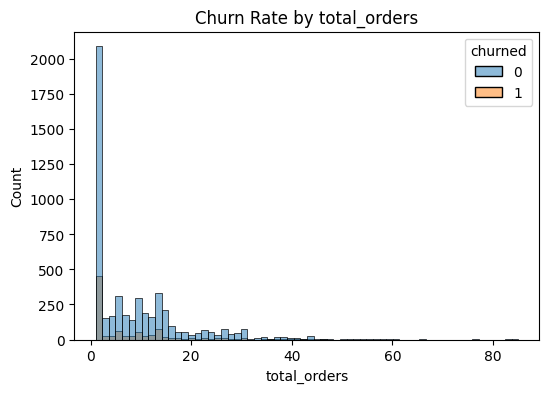

In [50]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='total_orders',hue='churned')
plt.title('Churn Rate by total_orders')
plt.show()

Customer Engagement & Activity

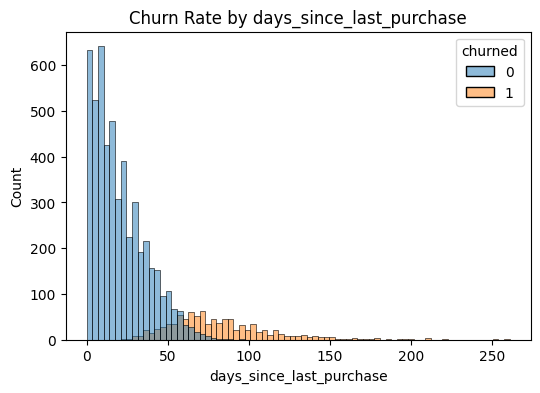

In [51]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='days_since_last_purchase',hue='churned')
plt.title('Churn Rate by days_since_last_purchase')
plt.show()

this mean that days since last order affect on churn in negative way

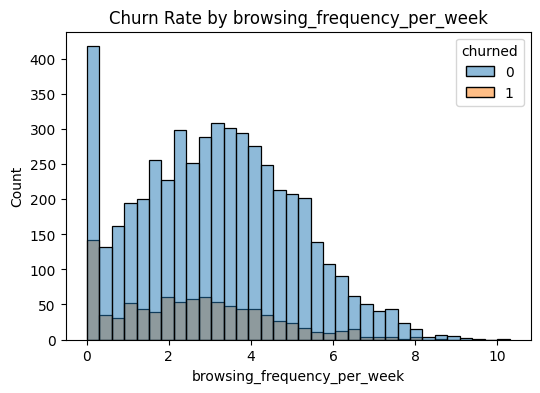

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='browsing_frequency_per_week',hue='churned')
plt.title('Churn Rate by browsing_frequency_per_week')
plt.show()

In [63]:
df.groupby('churned')['browsing_frequency_per_week'].mean()

churned
0    3.172195
1    2.555328
Name: browsing_frequency_per_week, dtype: float64

the browsing dosn't affect on churn

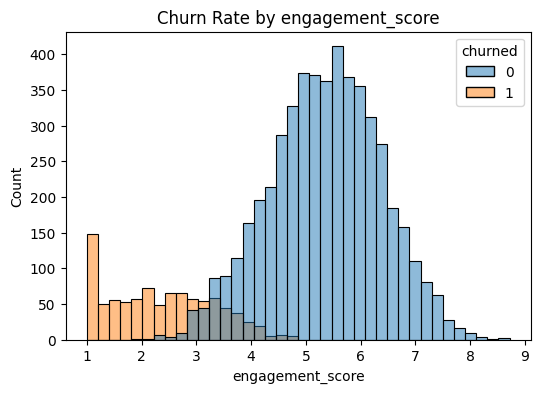

In [53]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='engagement_score',hue='churned')
plt.title('Churn Rate by engagement_score')
plt.show()

every time engagement score increase the chun is decrease

Customer Experience & Satisfaction

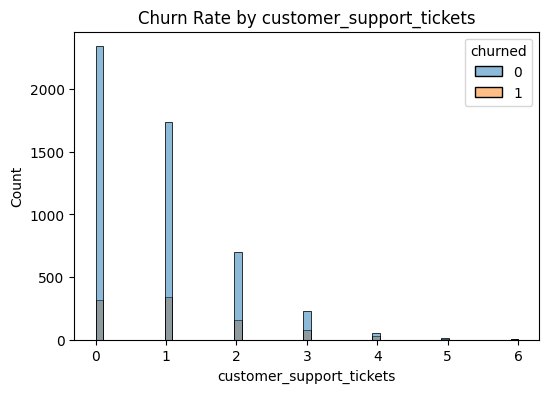

In [54]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='customer_support_tickets',hue='churned')
plt.title('Churn Rate by customer_support_tickets')
plt.show()

the increase of customer support increase churn

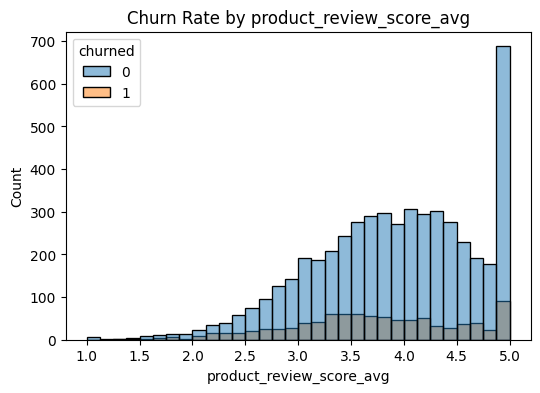

In [55]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='product_review_score_avg',hue='churned')
plt.title('Churn Rate by product_review_score_avg')
plt.show()

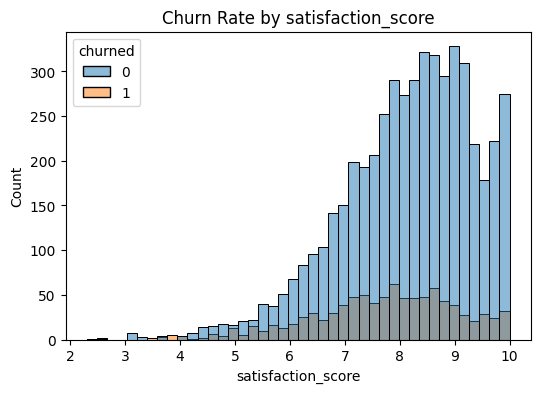

In [56]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='satisfaction_score',hue='churned')
plt.title('Churn Rate by satisfaction_score')
plt.show()

Pricing & Discount Behavior

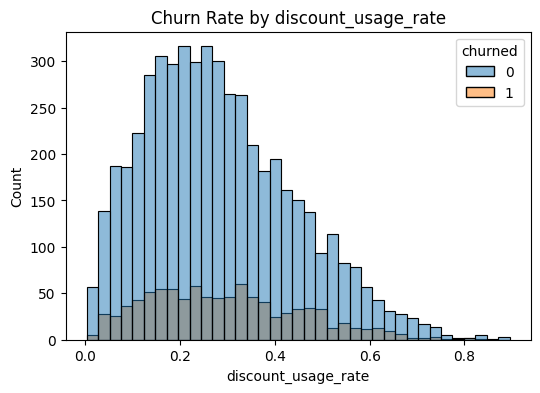

In [57]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='discount_usage_rate',hue='churned')
plt.title('Churn Rate by discount_usage_rate')
plt.show()

In [59]:
df.groupby('churned')['discount_usage_rate'].mean()

churned
0    0.283111
1    0.295679
Name: discount_usage_rate, dtype: float64

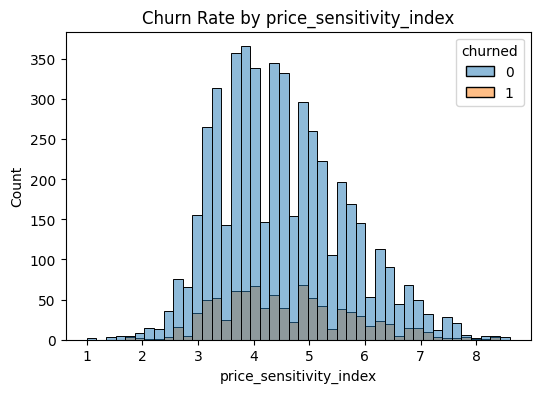

In [58]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='price_sensitivity_index',hue='churned')
plt.title('Churn Rate by price_sensitivity_index')
plt.show()

Purchase Friction & Risk Signals

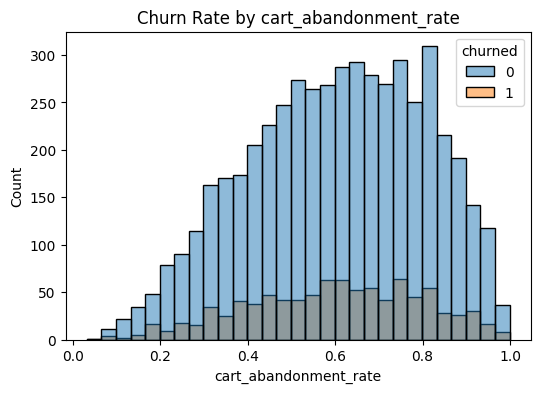

In [60]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='cart_abandonment_rate',hue='churned')
plt.title('Churn Rate by cart_abandonment_rate')
plt.show()

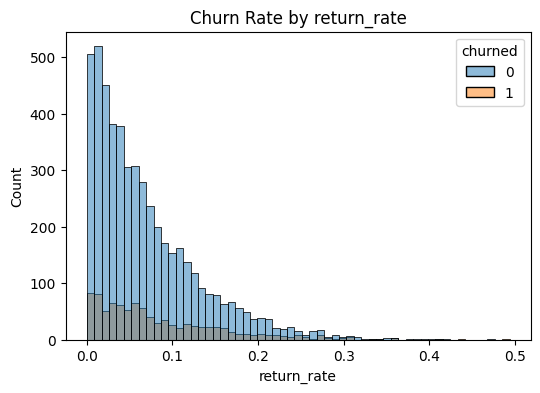

In [61]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df,x='return_rate',hue='churned')
plt.title('Churn Rate by return_rate')
plt.show()

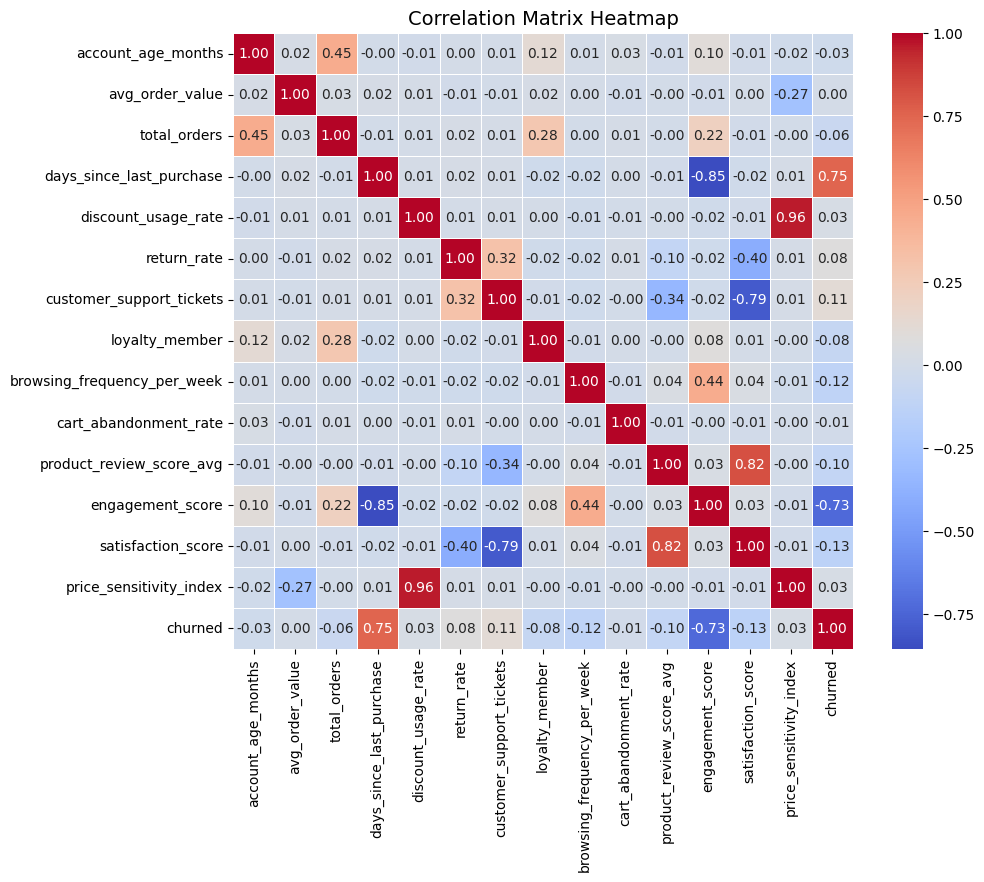

In [64]:
corr_matrix = df.corr(numeric_only=True)

# 2. رسم الـ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # لكتابة قيم الارتباط جوه المربعات
    cmap='coolwarm',  # ألوان متدرجة (أزرق للسالب / أحمر للموجب)
    fmt='.2f',  # تقريب الأرقام لعلامتين عشريتين
    linewidths=0.5,  # خطوط فاصلة بين المربعات
)

plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()

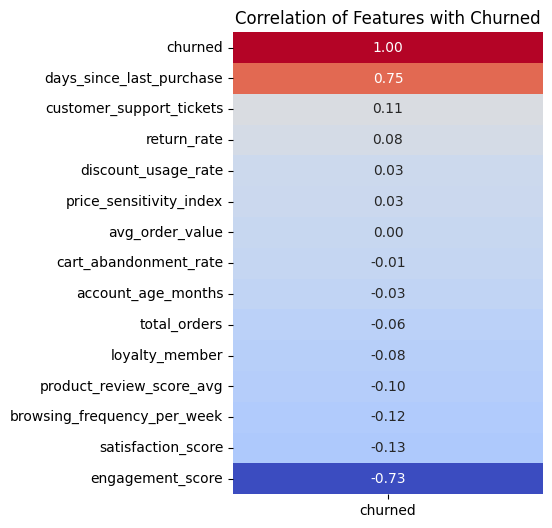

In [65]:
churn_corr = (
    df.corr(numeric_only=True)['churned'].sort_values(ascending=False).to_frame()
)

plt.figure(figsize=(4, 6))
sns.heatmap(
    churn_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    cbar=False,  # إلغاء شريط الألوان جانباً للتجميع
)

plt.title('Correlation of Features with Churned')
plt.show()

In [66]:
df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0


In [68]:
df.to_csv("Encoded_customer_data.csv", index=False)